In [41]:
from qiskit_aer import AerSimulator
from qiskit import QuantumCircuit, QuantumRegister,ClassicalRegister, transpile

from IPython.display import Math
from qc_workbook.show_state import statevector_expr

import numpy as np
import matplotlib.pyplot as plt

from qiskit.visualization import plot_distribution

from qiskit_aer.primitives import SamplerV2 as Sampler

print("----Start----")
simulator = AerSimulator(method='statevector')
print(simulator.name)

----Start----
aer_simulator_statevector


In [42]:
def get_statevector_array(circuit):
    circuit = circuit.copy()
    circuit.save_statevector()
    circuit = transpile(circuit, backend=simulator)
    job = simulator.run(circuit)
    result = job.result()
    qiskit_statevector = result.data()['statevector']

    return np.asarray(qiskit_statevector)

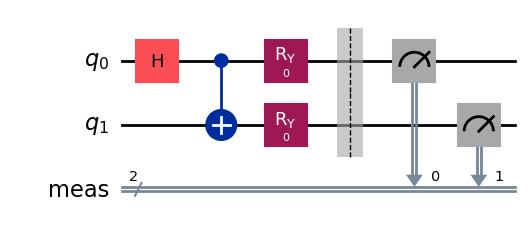

In [43]:
ntheta = 20
nchi = 20

thetas = np.linspace(0., np.pi, ntheta)
chis = np.linspace(0., np.pi, nchi)

circuits = []

for idx in np.ndindex(ntheta, nchi):
    theta = thetas[idx[0]]
    chi = chis[idx[1]]
    circuit = QuantumCircuit(2, name=f'circuit_{idx[0]}_{idx[1]}')

    circuit.h(0)
    circuit.cx(0,1)

    circuit.ry(theta,0)
    circuit.ry(chi,1)
    
    circuit.measure_all()
    circuits.append(circuit)
    
circuits[0].draw('mpl')
#circuits[1].draw('mpl')


In [44]:
sim = AerSimulator()

compiled_circuit = transpile(circuits, sim, optimization_level=0)

shots = 1000
job = sim.run(compiled_circuit, shots=shots) 
result = job.result()

#print(result)

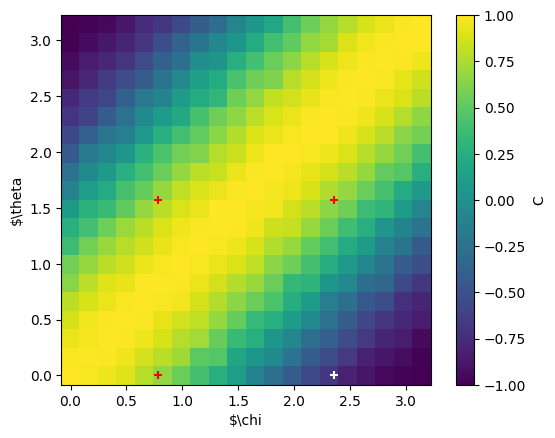

In [45]:
c_values = np.zeros((ntheta, nchi), dtype=float)

for icirc, idx in enumerate(np.ndindex(ntheta,nchi)):
    counts = result.get_counts(icirc)

    n00 = counts.get('00',0)
    n01 = counts.get('01',0)
    n10 = counts.get('10',0)
    n11 = counts.get('11',0)
    
    total_shots = n00+n01+n10+n11
    c_values[idx] = (n00+n11-n01-n10) / total_shots


dtheta = (thetas[1] - thetas[0]) * 0.5
dchi = (chis[1] - chis[0]) * 0.5
plt.imshow(c_values[::-1], extent=(chis[0]-dchi, chis[-1]+dchi, thetas[0]-dtheta, thetas[-1]+dtheta) )
plt.xlabel(r'$\chi')
plt.ylabel(r'$\theta')
plt.colorbar(label='C')

plt.scatter([np.pi/4., np.pi/4., 3.*np.pi/4.], [0., np.pi/2., np.pi/2.], c='red', marker='+')
plt.scatter([3. * np.pi / 4.], [0.], c='white', marker='+')